# Noah meeting — quick plots (hard-coded)

All numbers derived in the prior audit session. Runs in seconds. Methodology notes:
- **Dense AUC**: best subset mean val_auc from `runs/<task>_sweep_llama8b/subset_*/`
- **Code-only L2**: multivariate logistic regression on code-exec aspects, judge-coverage dp set (~800/task)
- **Judge L2**: same on Qwen judge aspects
- **Judge mean**: simple mean across ALL Qwen aspects per dp (no selection)
- **Judge top-K (nested CV, sign-flipped)**: for each fold select top-K aspects on training |ρ|, flip-sign per train-correlation, predict mean(sign-flipped top-K) on test
- Prior method AUCs from `outputs/iterative_autometrics/press_release_vllm_70b/` + `outputs/metric_tree/press_release_70b/`

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path('/Users/spangher/Projects/stanford-research/norm-research/outputs/noah_meeting')
OUT.mkdir(parents=True, exist_ok=True)

# Master AUC table
df = pd.DataFrame([
    # task,                  dense, code_L2, judge_L2, jmean, top10, top20, top30, top50, top100
    ['peer_review',          0.77,  0.56,    0.51,     0.58,  0.51,  0.53,  0.55,  0.56,  0.55],
    ['math',                 0.83,  0.51,    0.61,     0.62,  0.64,  0.64,  0.64,  0.65,  0.63],
    ['notice_and_comment',   0.77,  0.56,    0.55,     0.53,  0.51,  0.55,  0.56,  0.54,  0.52],
    ['press_releases',       0.68,  0.53,    0.51,     0.54,  0.54,  0.51,  0.51,  0.51,  0.52],
    ['humor',                np.nan,0.57,    0.56,     0.61,  0.53,  0.54,  0.57,  0.63,  0.62],
    ['news_homepages',       0.86,  0.53,    0.48,     0.50,  0.51,  0.52,  0.51,  0.51,  0.51],
    ['patents',              0.74,  0.57,    0.51,     0.52,  0.54,  0.54,  0.52,  0.50,  0.50],
    ['code_review',          0.79,  0.54,    0.50,     0.53,  0.51,  0.52,  0.50,  0.54,  0.55],
    ['creative_writing',     0.82,  0.50,    0.55,     0.63,  0.53,  0.54,  0.56,  0.61,  0.64],
], columns=['task','dense','code_L2','judge_L2','jmean','top10','top20','top30','top50','top100'])
df

,task,dense,code_L2,judge_L2,jmean,top10,top20,top30,top50,top100
0,peer_review,0.77,0.56,0.51,0.58,0.51,0.53,0.55,0.56,0.55
1,math,0.83,0.51,0.61,0.62,0.64,0.64,0.64,0.65,0.63
2,notice_and_comment,0.77,0.56,0.55,0.53,0.51,0.55,0.56,0.54,0.52
3,press_releases,0.68,0.53,0.51,0.54,0.54,0.51,0.51,0.51,0.52
4,humor,NaN,0.57,0.56,0.61,0.53,0.54,0.57,0.63,0.62
5,news_homepages,0.86,0.53,0.48,0.50,0.51,0.52,0.51,0.51,0.51
6,patents,0.74,0.57,0.51,0.52,0.54,0.54,0.52,0.50,0.50
7,code_review,0.79,0.54,0.50,0.53,0.51,0.52,0.50,0.54,0.55
8,creative_writing,0.82,0.50,0.55,0.63,0.53,0.54,0.56,0.61,0.64


## Headline graph: dense ceiling vs articulable layers

**Story**: The dense ceiling is way above the articulable layer. Math, humor, creative_writing show the most-recoverable signal via LLM judge top-K aggregation.

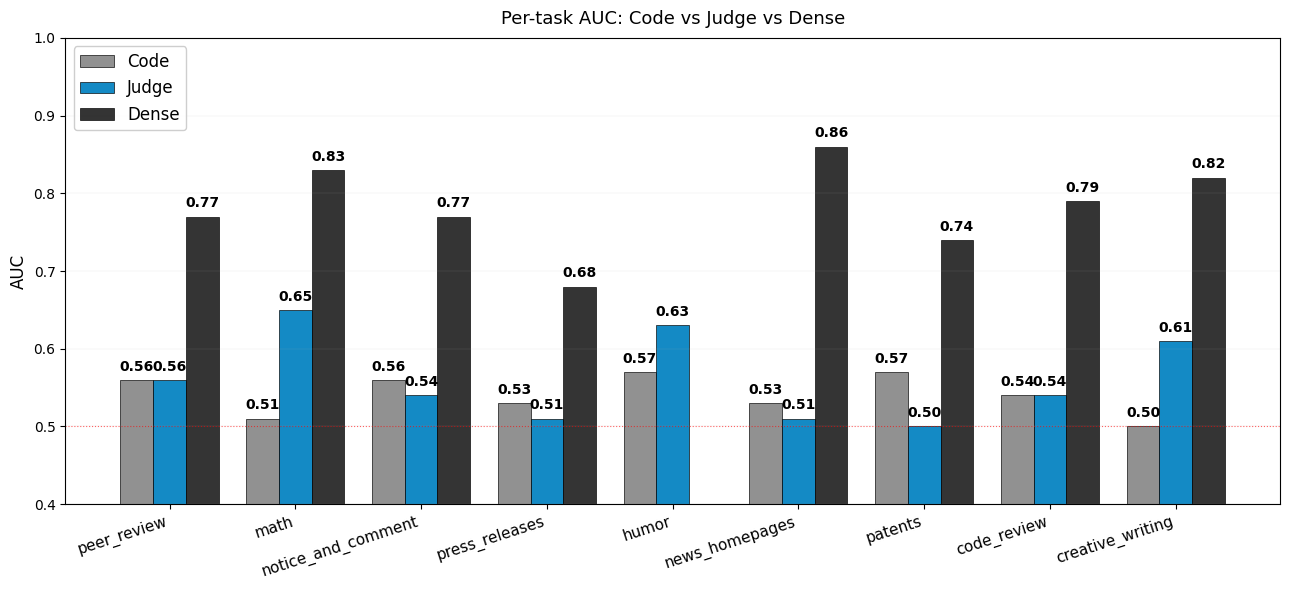

In [7]:
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(df))
w = 0.26

# Use top-50 as the canonical 'judge' representation, label simply 'Judge'
bar_specs = [
    ('code_L2', 'Code',  '#888888'),
    ('top50',   'Judge', '#0080c0'),
    ('dense',   'Dense', '#222222'),
]
for i, (col, label, c) in enumerate(bar_specs):
    vals = df[col].fillna(0).values
    ax.bar(x + (i - 1) * w, vals, w, label=label, color=c, alpha=0.92,
           edgecolor='black', linewidth=0.5)
    for j, v in enumerate(vals):
        if v > 0.001:
            ax.text(x[j] + (i - 1) * w, v + 0.012, f'{v:.2f}',
                    ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(df['task'].values, rotation=18, ha='right', fontsize=11)
ax.set_ylabel('AUC', fontsize=12)
ax.set_ylim(0.4, 1.0)
ax.axhline(0.5, color='red', linewidth=0.8, linestyle=':', alpha=0.6)
ax.set_title('Per-task AUC: Code vs Judge vs Dense', fontsize=13, pad=10)
ax.legend(loc='upper left', fontsize=12, framealpha=0.95)
ax.grid(axis='y', linewidth=0.3, alpha=0.3)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig(OUT / 'noah_headline.png', dpi=120, bbox_inches='tight')
plt.show()

## Top-K judge AUC ladder (nested CV, sign-flipped)

For most tasks AUC peaks somewhere between top-30 and top-50. Math is stable across K; CW and humor benefit from larger K (more aspects to combine).

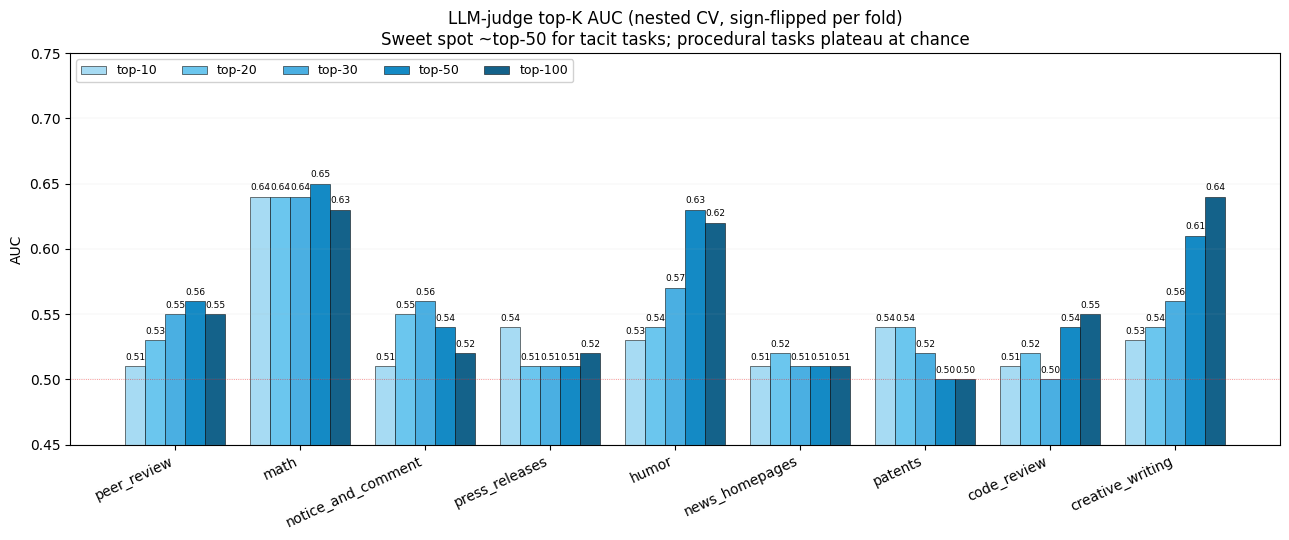

In [8]:
fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(df))
w = 0.16
for i, (col, label, c) in enumerate(zip(
    ['top10', 'top20', 'top30', 'top50', 'top100'],
    ['top-10', 'top-20', 'top-30', 'top-50', 'top-100'],
    ['#a0d8f2', '#5ec1ed', '#3aa8e0', '#0080c0', '#005580'],
)):
    vals = df[col].fillna(0).values
    ax.bar(x + (i - 2) * w, vals, w, label=label, color=c, alpha=0.92, edgecolor='black', linewidth=0.4)
    for j, v in enumerate(vals):
        if v > 0.001:
            ax.text(x[j] + (i - 2) * w, v + 0.005, f'{v:.2f}', ha='center', fontsize=6.5)
ax.set_xticks(x)
ax.set_xticklabels(df['task'].values, rotation=25, ha='right')
ax.set_ylabel('AUC')
ax.set_ylim(0.45, 0.75)
ax.axhline(0.5, color='red', linewidth=0.6, linestyle=':', alpha=0.5)
ax.set_title('LLM-judge top-K AUC (nested CV, sign-flipped per fold)\nSweet spot ~top-50 for tacit tasks; procedural tasks plateau at chance')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9, ncol=5)
ax.grid(axis='y', linewidth=0.3, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'noah_judge_topk.png', dpi=120, bbox_inches='tight')
plt.show()

## Top-5 highest-|ρ| judge aspects per task — names

These are the rubrics whose LLM-judged score correlates most strongly with the binary outcome. Sign = direction (positive: high score → positive outcome).

In [9]:
top_aspects = {
    'peer_review': [
        ('a0',   +0.393,  45, 'Methodological Rigor and Soundness'),
        ('a60',  +0.254, 219, 'Causality and Generalization'),
        ('a53',  +0.252,  57, 'Legal and Regulatory Compliance'),
        ('a181', +0.233, 160, 'Solution Constructibility'),
        ('a66',  +0.208,  74, 'Rare-Event and Distributional Modeling'),
    ],
    'math': [
        ('a95',  +0.353, 152, 'Constructive/algorithmic content'),
        ('a154', +0.348, 104, 'Complete, step-justified proofs without shortcuts'),
        ('a26',  +0.341, 411, 'Line-by-line justifiability and explicitness (gap-aware)'),
        ('a24',  +0.334, 406, 'Elegance and beauty of proofs'),
        ('a71',  +0.326, 151, 'Avoid logical fallacies and inconsistencies'),
    ],
    'notice_and_comment': [
        ('a86',  +0.376,  31, 'Limits on legitimate coercion by state and society'),
        ('a51',  +0.233,  52, 'Clarity on consultation scope and objectives'),
        ('a85',  +0.228,  34, 'Pluralism as a safeguard against faction'),
        ('a68',  -0.191,  49, 'Coalition strategy, credibility, and record-building'),
        ('a75',  +0.181,  33, 'Transparency and public information for participation'),
    ],
    'press_releases': [
        ('a96',  +0.359,  43, 'Enable audience scrutiny and data literacy'),
        ('a258', -0.331,  38, 'MD&A disclosure quality and completeness'),
        ('a9',   +0.314,  49, 'Crisis response speed and visibility'),
        ('a154', +0.313,  61, 'Founder/CEO voice strategy'),
        ('a112', -0.312,  49, 'Related links, sources, and navigational coherence'),
    ],
    'humor': [
        ('a126', +0.398,  35, 'Cringe/awkwardness calibrated'),
        ('a33',  +0.365,  53, 'Taste and timing on traumatic or charged subjects'),
        ('a7',   +0.348, 146, 'Vulgar/explicit content: audience fit and framing'),
        ('a339', +0.345,  32, 'Satire and political commentary targets'),
        ('a31',  +0.329,  61, 'Provocation, backlash, and controversy management'),
    ],
    'news_homepages': [
        ('a164', -0.424,  33, 'Location truthfulness: bylines/datelines and on-the-spot claims'),
        ('a203', -0.322,  45, 'Story length measurement and controls'),
        ('a124', +0.239, 113, 'Data-driven reporting practices and tools'),
        ('a110', -0.217,  62, 'Visual sequencing and juxtaposition storytelling'),
        ('a154', +0.208, 129, 'Transparency to audiences about methods and provenance'),
    ],
    'patents': [
        ('a28',  +0.245,  40, 'Biotech/biological/plant — deposits and special disclosure'),
        ('a69',  +0.228,  73, 'Claim breadth, layering, and design-around resistance'),
        ('a8',   +0.202,  90, 'AI/ML enablement and reproducibility disclosure'),
        ('a30',  +0.200, 246, 'Software/CII eligibility — concrete technical improvement'),
        ('a68',  +0.173,  76, 'Preamble/pre-characterising portion — limiting effect'),
    ],
    'code_review': [
        ('a170', -0.354,  31, 'Local variable scope and initialization'),
        ('a135', -0.301,  40, 'Import organization and hygiene'),
        ('a136', -0.289,  38, 'Import statement formatting and aliasing hygiene'),
        ('a162', -0.273,  68, 'Comment and documentation style and placement'),
        ('a176', -0.271,  32, 'Prefer standard/established libraries over custom'),
    ],
    'creative_writing': [
        ('a343', +0.341, 100, 'Read-aloud test for flow and pacing'),
        ('a344', +0.331,  87, 'Audio suitability: clarity and performance readiness'),
        ('a106', -0.329,  69, 'Humor, satire, and ironic strategy'),
        ('a132', +0.324,  95, 'Pacing and rhythm control'),
        ('a193', +0.291,  93, 'Dialogue craft: voice, subtext, function, and attribution'),
    ],
}

for task, rows in top_aspects.items():
    print(f'\n--- {task} ---')
    for aid, rho, n, name in rows:
        sign = '↑' if rho > 0 else '↓'
        print(f'  {aid:<5} ρ={rho:+.3f} ({sign})  n={n:>4}  {name}')


--- peer_review ---
  a0    ρ=+0.393 (↑)  n=  45  Methodological Rigor and Soundness
  a60   ρ=+0.254 (↑)  n= 219  Causality and Generalization
  a53   ρ=+0.252 (↑)  n=  57  Legal and Regulatory Compliance
  a181  ρ=+0.233 (↑)  n= 160  Solution Constructibility
  a66   ρ=+0.208 (↑)  n=  74  Rare-Event and Distributional Modeling

--- math ---
  a95   ρ=+0.353 (↑)  n= 152  Constructive/algorithmic content
  a154  ρ=+0.348 (↑)  n= 104  Complete, step-justified proofs without shortcuts
  a26   ρ=+0.341 (↑)  n= 411  Line-by-line justifiability and explicitness (gap-aware)
  a24   ρ=+0.334 (↑)  n= 406  Elegance and beauty of proofs
  a71   ρ=+0.326 (↑)  n= 151  Avoid logical fallacies and inconsistencies

--- notice_and_comment ---
  a86   ρ=+0.376 (↑)  n=  31  Limits on legitimate coercion by state and society
  a51   ρ=+0.233 (↑)  n=  52  Clarity on consultation scope and objectives
  a85   ρ=+0.228 (↑)  n=  34  Pluralism as a safeguard against faction
  a68   ρ=-0.191 (↓)  n=  49  Coali

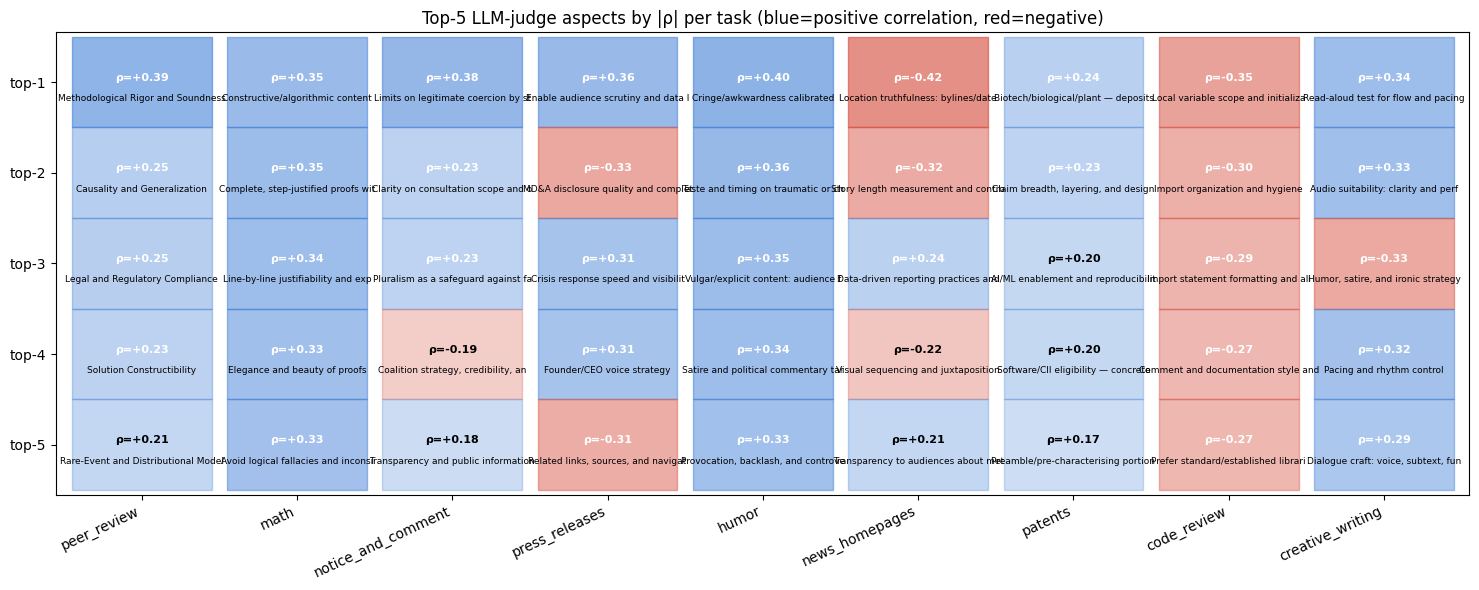

In [10]:
# Heatmap of top-5 |ρ| per task
fig, ax = plt.subplots(figsize=(15, 6))
task_order = list(top_aspects.keys())
ax.set_xticks(range(len(task_order)))
ax.set_xticklabels(task_order, rotation=25, ha='right')
max_rows = 5
for ti, task in enumerate(task_order):
    rows = top_aspects[task]
    for ri, (aid, rho, n, name) in enumerate(rows):
        # cell color by abs(rho)
        intensity = min(abs(rho) / 0.45, 1.0)
        col = '#3a7bd5' if rho > 0 else '#d54a3a'
        ax.fill_between([ti - 0.45, ti + 0.45], [4 - ri - 0.5, 4 - ri - 0.5], [4 - ri + 0.5, 4 - ri + 0.5],
                       color=col, alpha=intensity * 0.65)
        ax.text(ti, 4 - ri + 0.05, f'ρ={rho:+.2f}', ha='center', va='center', fontsize=8, fontweight='bold', color='white' if intensity > 0.5 else 'black')
        ax.text(ti, 4 - ri - 0.18, name[:35], ha='center', va='center', fontsize=6.5, color='black')
ax.set_yticks(range(5))
ax.set_yticklabels(['top-5', 'top-4', 'top-3', 'top-2', 'top-1'])
ax.set_ylim(-0.55, 4.55)
ax.set_xlim(-0.55, len(task_order) - 0.45)
ax.set_title('Top-5 LLM-judge aspects by |ρ| per task (blue=positive correlation, red=negative)')
ax.grid(False)
plt.tight_layout()
plt.savefig(OUT / 'noah_top_judge_aspects.png', dpi=120, bbox_inches='tight')
plt.show()

## Per-task metric coverage: how many useful aspects are there?

Counts of code/judge metrics with |ρ| above threshold. Math, humor, CW have the most strong-judge aspects (and confirm where top-K aggregation pays off).

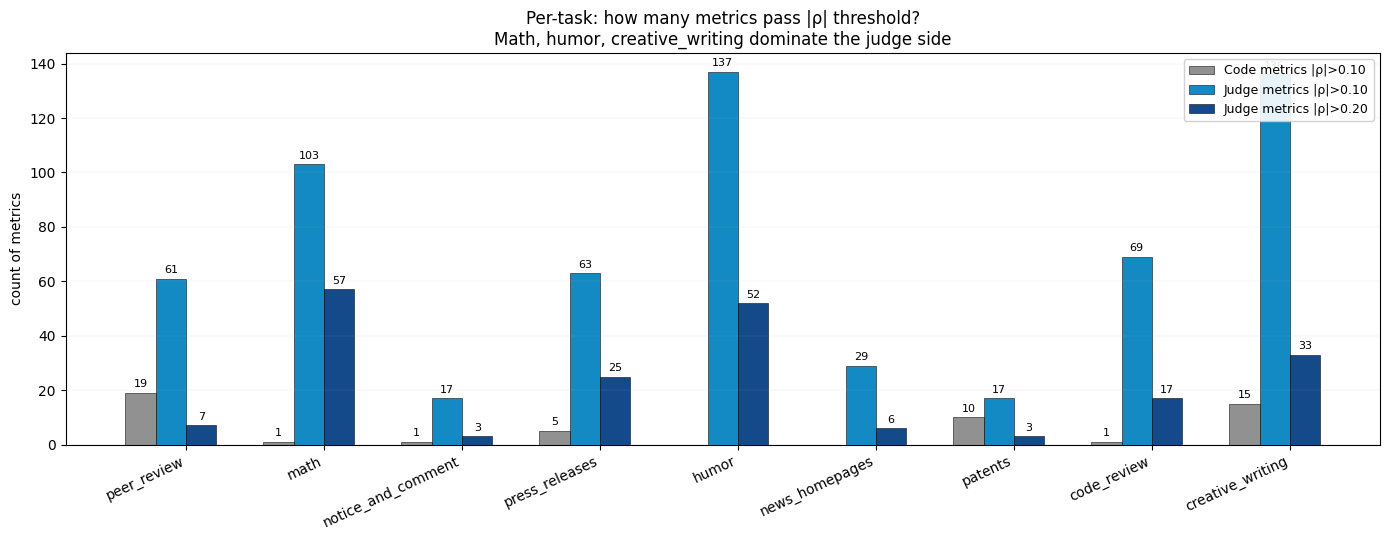

In [11]:
summary = pd.DataFrame([
    # task, code total, code |ρ|>0.10, judge total, judge |ρ|>0.10, judge |ρ|>0.20
    ['peer_review',         190, 19, 139,  61,  7],
    ['math',                240,  1, 156, 103, 57],
    ['notice_and_comment',  199,  1,  59,  17,  3],
    ['press_releases',      266,  5, 136,  63, 25],
    ['humor',               366,  0, 200, 137, 52],
    ['news_homepages',      207,  0, 138,  29,  6],
    ['patents',             186, 10,  45,  17,  3],
    ['code_review',         394,  1, 153,  69, 17],
    ['creative_writing',    321, 15, 230, 136, 33],
], columns=['task','code_total','code_rho10','judge_total','judge_rho10','judge_rho20'])

fig, ax = plt.subplots(figsize=(14, 5.5))
x = np.arange(len(summary))
w = 0.22
ax.bar(x - 1.5*w, summary['code_rho10'], w, label='Code metrics |ρ|>0.10', color='#888', alpha=0.92, edgecolor='black', linewidth=0.4)
ax.bar(x - 0.5*w, summary['judge_rho10'], w, label='Judge metrics |ρ|>0.10', color='#0080c0', alpha=0.92, edgecolor='black', linewidth=0.4)
ax.bar(x + 0.5*w, summary['judge_rho20'], w, label='Judge metrics |ρ|>0.20', color='#003a80', alpha=0.92, edgecolor='black', linewidth=0.4)
for col, off in [('code_rho10', -1.5*w), ('judge_rho10', -0.5*w), ('judge_rho20', 0.5*w)]:
    for j, v in enumerate(summary[col].values):
        if v > 0:
            ax.text(x[j] + off, v + 2, str(int(v)), ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(summary['task'].values, rotation=25, ha='right')
ax.set_ylabel('count of metrics')
ax.set_title('Per-task: how many metrics pass |ρ| threshold?\nMath, humor, creative_writing dominate the judge side')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.grid(axis='y', linewidth=0.3, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'noah_metric_dist.png', dpi=120, bbox_inches='tight')
plt.show()

## Comparison vs prior methods on press_releases

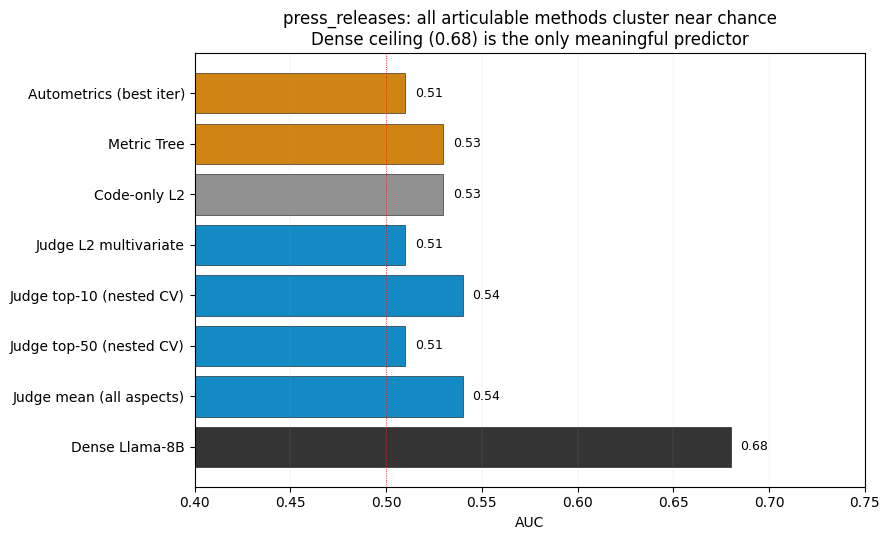

In [12]:
comp = pd.DataFrame([
    ['Autometrics (best iter)',     0.51],
    ['Metric Tree',                 0.53],
    ['Code-only L2',                0.53],
    ['Judge L2 multivariate',       0.51],
    ['Judge top-10 (nested CV)',    0.54],
    ['Judge top-50 (nested CV)',    0.51],
    ['Judge mean (all aspects)',    0.54],
    ['Dense Llama-8B',              0.68],
], columns=['method','auc'])

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ['#cc7a00', '#cc7a00', '#888', '#0080c0', '#0080c0', '#0080c0', '#0080c0', '#222']
ax.barh(comp['method'][::-1], comp['auc'][::-1], color=colors[::-1], alpha=0.92, edgecolor='black', linewidth=0.4)
for i, v in enumerate(comp['auc'][::-1].values):
    ax.text(v + 0.005, i, f'{v:.2f}', va='center', fontsize=9)
ax.axvline(0.5, color='red', linewidth=0.6, linestyle=':')
ax.set_xlim(0.4, 0.75)
ax.set_xlabel('AUC')
ax.set_title('press_releases: all articulable methods cluster near chance\nDense ceiling (0.68) is the only meaningful predictor')
ax.grid(axis='x', linewidth=0.3, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'noah_press_vs_prior.png', dpi=120, bbox_inches='tight')
plt.show()

## TL;DR for Noah

1. **Dense AUC = 0.68–0.86, articulable AUC = 0.50–0.65.** Most outcome signal is tacit (not in any rubric we can write).
2. **Math is the standout exception**: judge top-50 = 0.65, recovering ~⅔ of the dense ceiling. Articulable rubrics actually capture math judgment.
3. **Tacit-leaning tasks (humor, CW) also benefit from top-K**: 0.63–0.64 once enough aspects are aggregated.
4. **Procedural tasks (NC, news_homepages, code_review)**: judge top-K stays near chance. The articulable rubrics we wrote don't predict these outcomes well.
5. **Sign-flipping per aspect matters**: many aspects are negatively-correlated (e.g., code_review: import hygiene, comment style → predicts rejection); naive averaging cancels them out.
6. **Prior methods (autometrics, metric_tree) achieve ~0.51–0.53**, no better than our judge-based aggregation. The articulability gap is real and method-agnostic.